In [1]:
#import spatialdata as sd
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq
import anndata as ad


from scipy import stats
 
import pickle
 

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: 

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
#%matplotlib inline
sc.settings.figdir = "fig4"
sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(8,8))


# Load

In [3]:
FILE_NAME = "adata_combined_new.h5ad.final.filtered"
PATH2=f'/nfs/team298/ls34/adult_skin/final_adatas/{FILE_NAME}'
adata_5k=sc.read_h5ad(PATH2)
adata_5k=adata_5k[adata_5k.obs["tech"]=="xenium"]


def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata_5k.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata_5k.var_names]
    return LIST

 

adata_5k



View of AnnData object with n_obs × n_vars = 1418806 × 4993
    obs: 'sample_id', 'barcode', 'GSE', 'Site_status', 'Patient_status', 'Location', 'Age', 'Sex', 'n_genes', 'dataset_id', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'QC_hi', 'QC_mid', 'lvl5_annotation', 'Mapping_status', 'scanvi_predictions', 'lvl5_annotation_new', 'lvl5_annotation_new2', 'lvl5_annotation_new3', 'lvl5_annotation_new_archive', 'lvl5_annotation_new_preoprhan', 'lvl5_annotation_new10', 'lvl5_annotation_new11', 'test', 'test_n', 'lvl5_annotation_new12', 'lvl5_annotation_new13', 'lvl4_annotation', 'lvl0', 'temp', 't', 'leiden_res0.1', 'Site_status_simple', 'StatusMilo', 'atlas_status', 'atlas_status_reynolds', 'atlas_status_reynolds_simple', 'atlas_status_simple', 'atlas_status_simple2', 'Site_status_binary', 'scanvi_labels

In [4]:
# subset = adata_5k.obs[adata_5k.obs["niche19"] == "Plasma_cell_rich"]
# proportion_data = subset.groupby("Sanger patient ID").size() / adata_5k.obs.groupby("Sanger patient ID").size()

# data = pd.DataFrame({
#     "baseline_severity": adata_5k.obs.groupby("Sanger patient ID")["baseline_severity"].first().astype(float),
#     "proportion_epidermis_mid_inflammatory": proportion_data
# }).reset_index()

# plt.figure(figsize=(4,4), dpi=600)
# plt.scatter(
#     data["baseline_severity"],
#     data["proportion_epidermis_mid_inflammatory"],
#     color="lightcoral", alpha=0.8, s=60  # Changed to light orange (lightcoral)
# )

# texts = []
# for _, row in data.iterrows():
#     texts.append(plt.text(row["baseline_severity"], row["proportion_epidermis_mid_inflammatory"],
#                           row["Sanger patient ID"], fontsize=10))  # Increased font size to 10

# plt.xlabel("Overall Disease severity score" ,fontsize=10 )
# plt.ylabel("Proportion Epidermis Mid Inflammatory", fontsize=10 )

# ax = plt.gca()
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

# plt.grid(False)
# plt.tight_layout()
# plt.show()

/tmp/ipykernel_4187013/3021192638.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  proportion_data = subset.groupby("Sanger patient ID").size() / adata_5k.obs.groupby("Sanger patient ID").size()
/tmp/ipykernel_4187013/3021192638.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  proportion_data = subset.groupby("Sanger patient ID").size() / adata_5k.obs.groupby("Sanger patient ID").size()
/tmp/ipykernel_4187013/3021192638.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=Tru

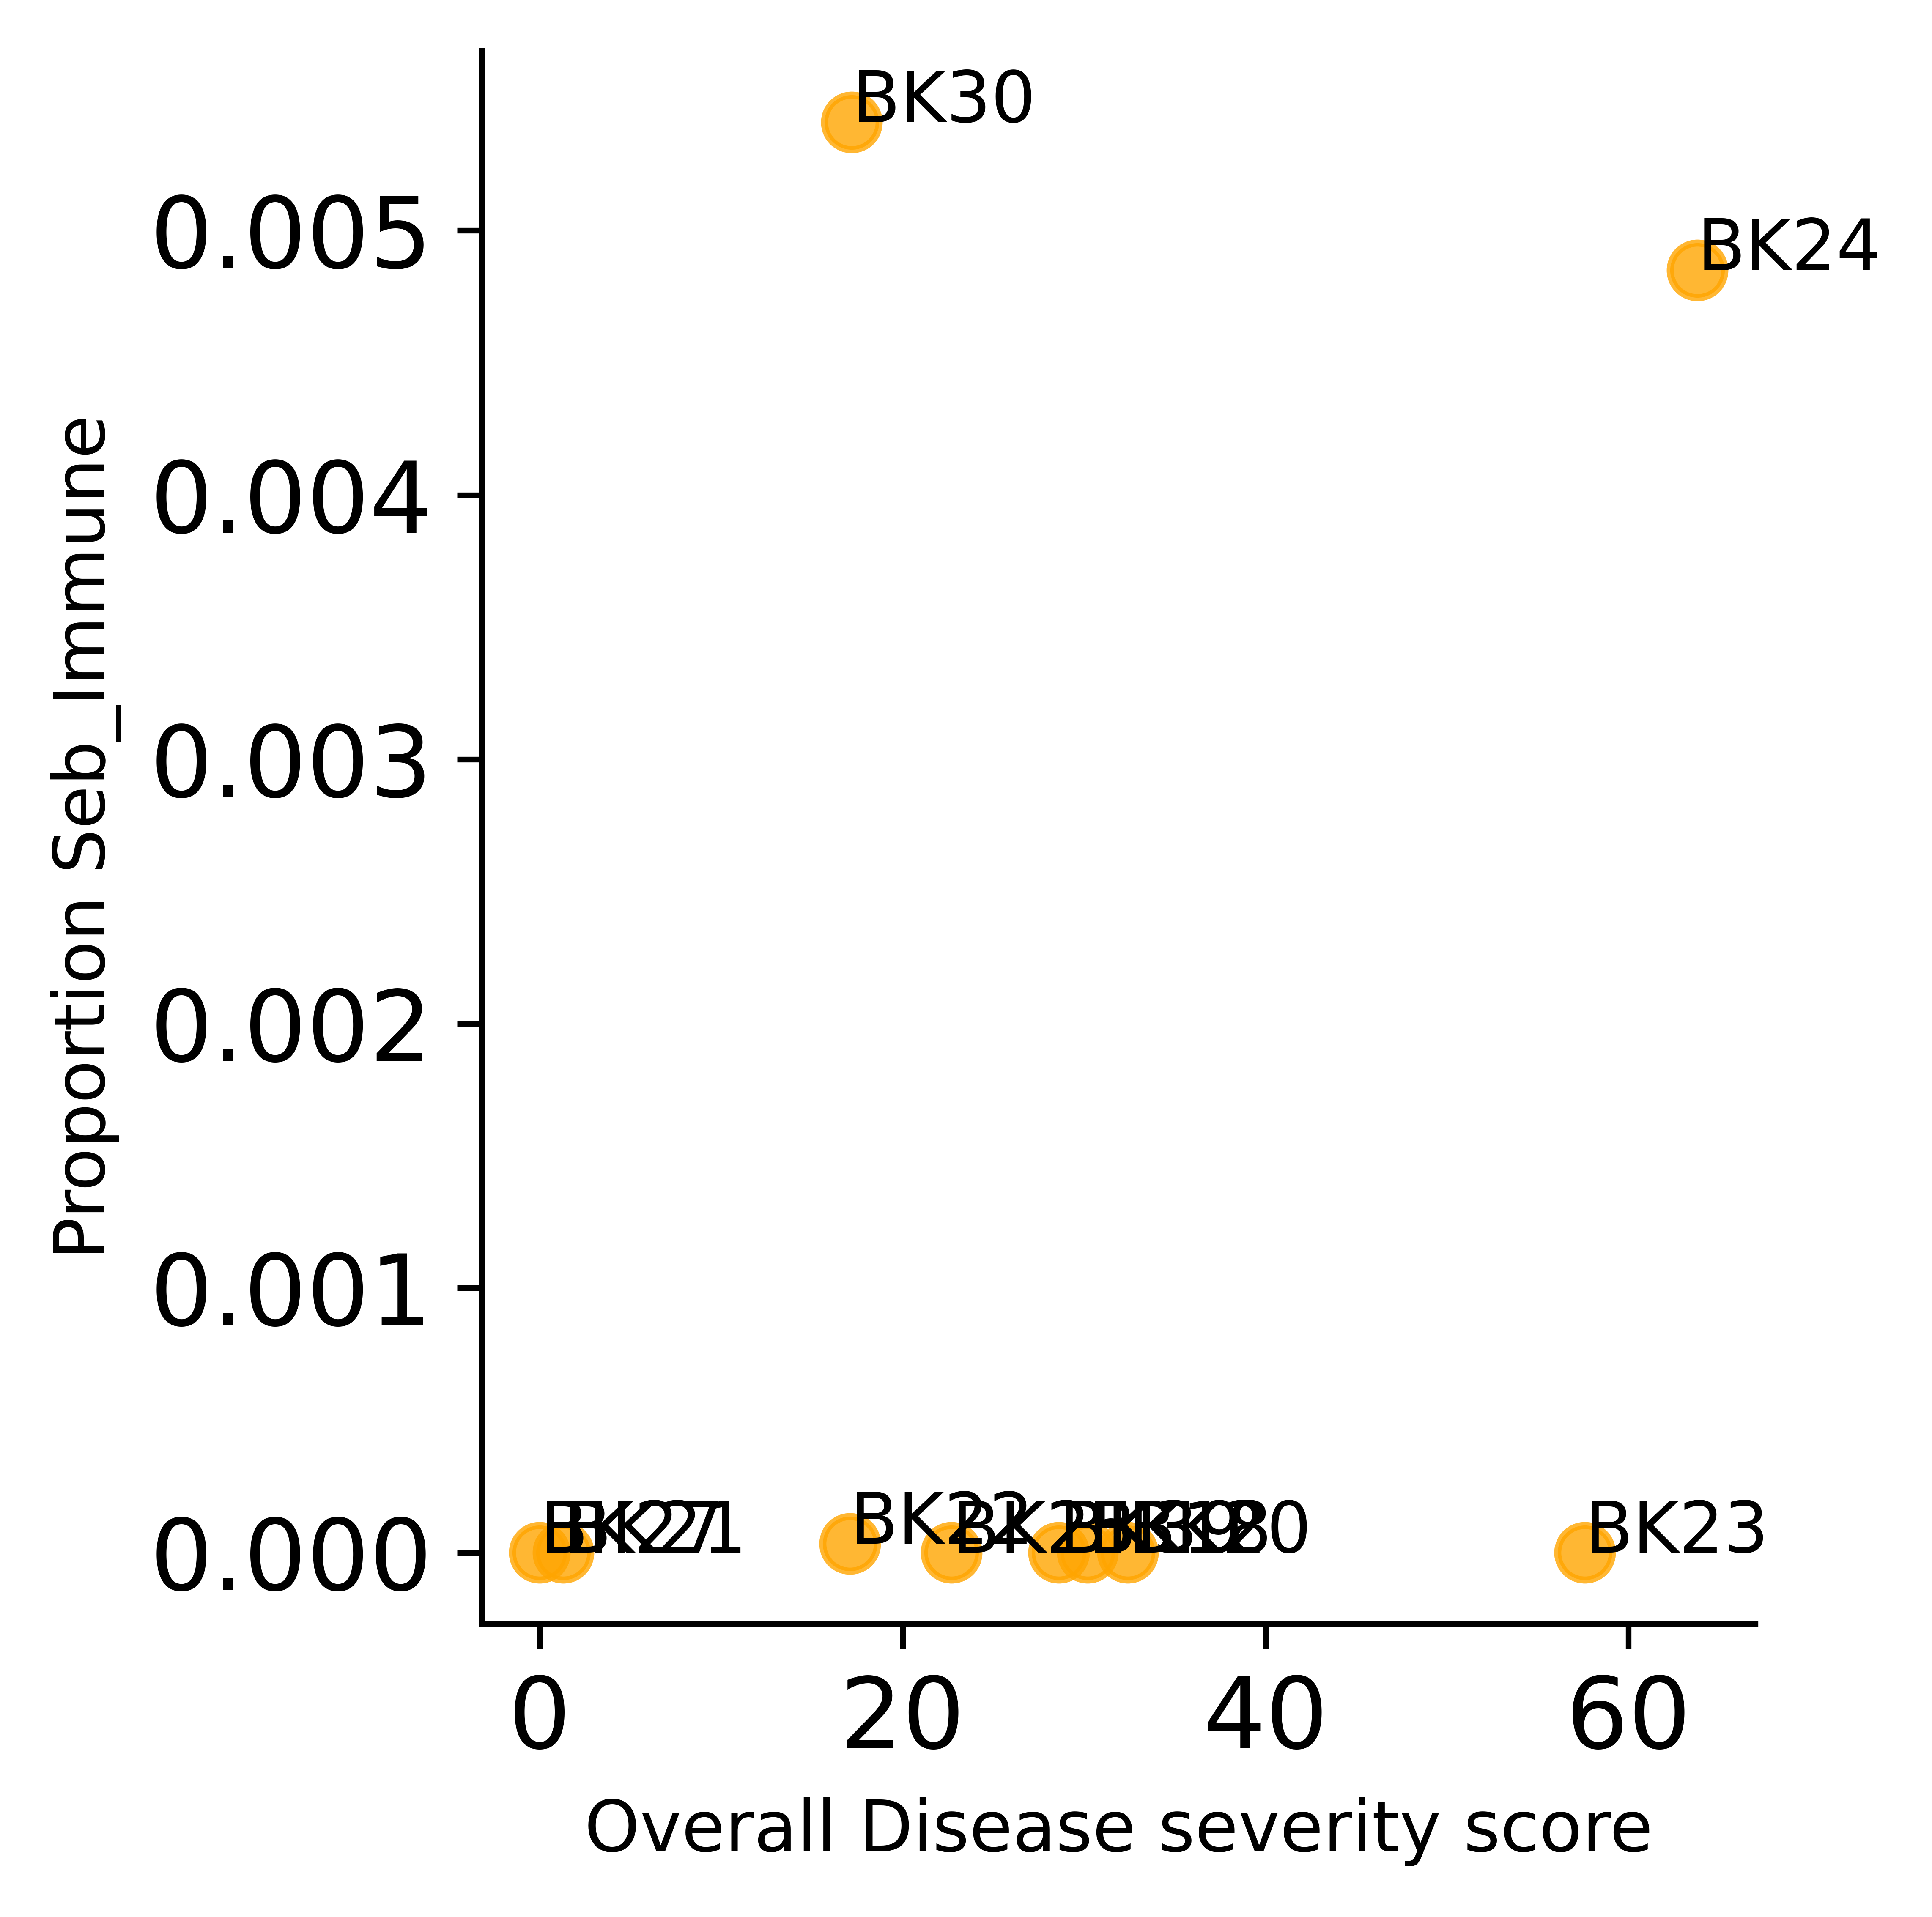

In [5]:
adata_5k_i=adata_5k[adata_5k.obs["Site_status"]=="Non-lesional"]

subset = adata_5k_i.obs[adata_5k_i.obs["niche19"] == "Sebaceous_immune"]
proportion_data = subset.groupby("Sanger patient ID").size() / adata_5k.obs.groupby("Sanger patient ID").size()


data = pd.DataFrame({
    "baseline_severity": adata_5k.obs.groupby("Sanger patient ID")["baseline_severity"].first().astype(float),
    "proportion_epidermis_mid_inflammatory": proportion_data
}).reset_index()

plt.figure(figsize=(4,4), dpi=600)
plt.scatter(
    data["baseline_severity"],
    data["proportion_epidermis_mid_inflammatory"],
    color="orange", alpha=0.8, s=60  # Changed to light orange (lightcoral)
)

texts = []
for _, row in data.iterrows():
    texts.append(plt.text(row["baseline_severity"], row["proportion_epidermis_mid_inflammatory"],
                          row["Sanger patient ID"], fontsize=10))  # Increased font size to 10

plt.xlabel("Overall Disease severity score" ,fontsize=10 )
plt.ylabel("Proportion Seb_Immune", fontsize=10 )

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid(False)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4187013/1245142144.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  proportion_data = subset.groupby("Sanger patient ID").size() / adata_5k.obs.groupby("Sanger patient ID").size()
/tmp/ipykernel_4187013/1245142144.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  proportion_data = subset.groupby("Sanger patient ID").size() / adata_5k.obs.groupby("Sanger patient ID").size()
/tmp/ipykernel_4187013/1245142144.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=Tru

FileNotFoundError: [Errno 2] No such file or directory: 'fig3/3L_NONLESIONAL_SEVERITY.pdf'

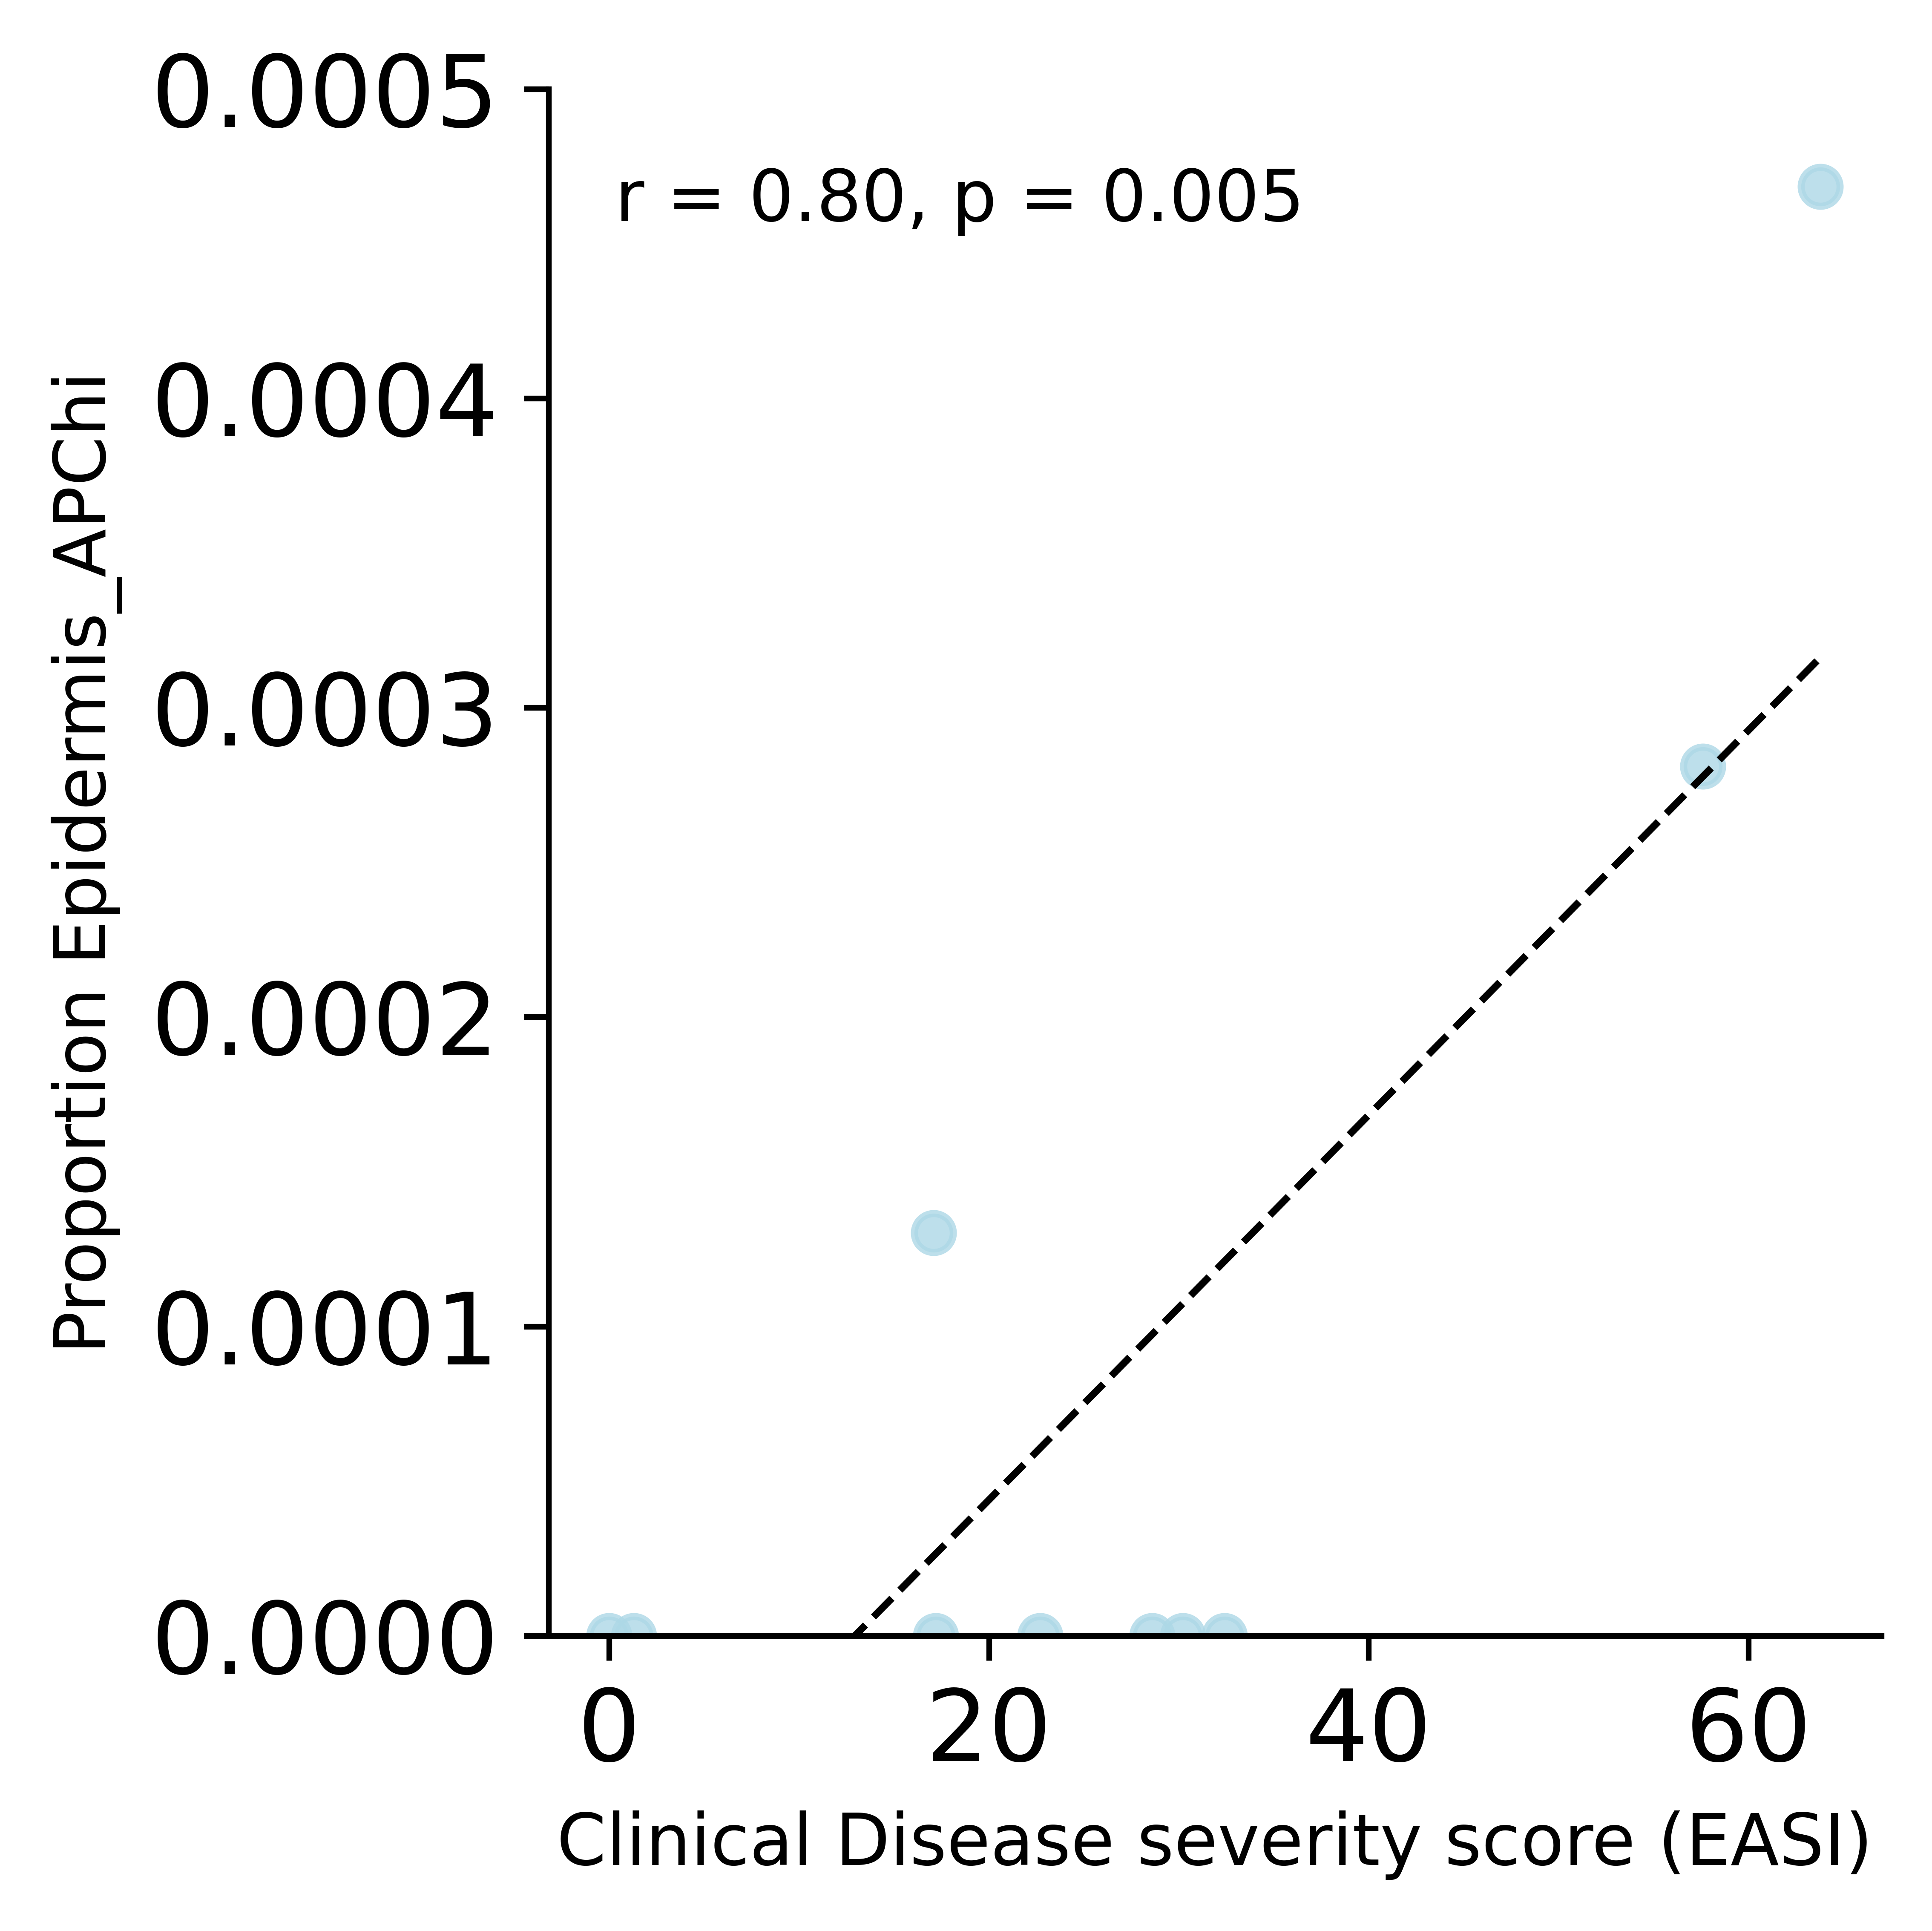

In [6]:
# adata_5k_i = adata_5k[adata_5k.obs["Site_status"] == "Non-lesional"]

# subset = adata_5k_i.obs[adata_5k_i.obs["niche19"] == "Epidermis_APChi"]
# proportion_data = subset.groupby("Sanger patient ID").size() / adata_5k.obs.groupby("Sanger patient ID").size()

# data = pd.DataFrame({
#     "baseline_severity": adata_5k.obs.groupby("Sanger patient ID")["baseline_severity"].first().astype(float),
#     "proportion_epidermis_mid_inflammatory": proportion_data
# }).reset_index()

# data = data.replace([np.inf, -np.inf], np.nan).dropna(
#     subset=["baseline_severity", "proportion_epidermis_mid_inflammatory"]
# )

# from adjustText import adjust_text

# plt.figure(figsize=(4,4), dpi=600)
# plt.scatter(
#     data["baseline_severity"],
#     data["proportion_epidermis_mid_inflammatory"],
#     color="lightblue", alpha=0.8, s=30
# )

# x = data["baseline_severity"]
# y = data["proportion_epidermis_mid_inflammatory"]

# r, pval = stats.pearsonr(x, y)

# slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
# line_x = np.linspace(x.min(), x.max(), 100)
# line_y = slope * line_x + intercept
# plt.plot(line_x, line_y, color="black", linestyle="--", linewidth=1)

# if pval < 0.001:
#     p_text = "<0.001"
# else:
#     p_text = f"{pval:.3f}"

# plt.text(
#     0.05, 0.95,
#     f"r = {r:.2f}, p = {p_text}",
#     transform=plt.gca().transAxes,
#     ha="left", va="top", fontsize=10
# )

# plt.xlabel("Clinical Disease severity score (EASI)", fontsize=10)
# plt.ylabel("Proportion Epidermis_APChi", fontsize=10)
# plt.ylim(0, 0.0005)

# ax = plt.gca()
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

# plt.grid(False)
# plt.tight_layout()
# plt.savefig("fig3/3L_NONLESIONAL_SEVERITY.pdf", dpi=300, bbox_inches="tight")
# plt.show()

/tmp/ipykernel_4187013/3357398599.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  proportion_data = subset.groupby("Sanger patient ID").size() / adata_5k.obs.groupby("Sanger patient ID").size()
/tmp/ipykernel_4187013/3357398599.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  proportion_data = subset.groupby("Sanger patient ID").size() / adata_5k.obs.groupby("Sanger patient ID").size()
/tmp/ipykernel_4187013/3357398599.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=Tru

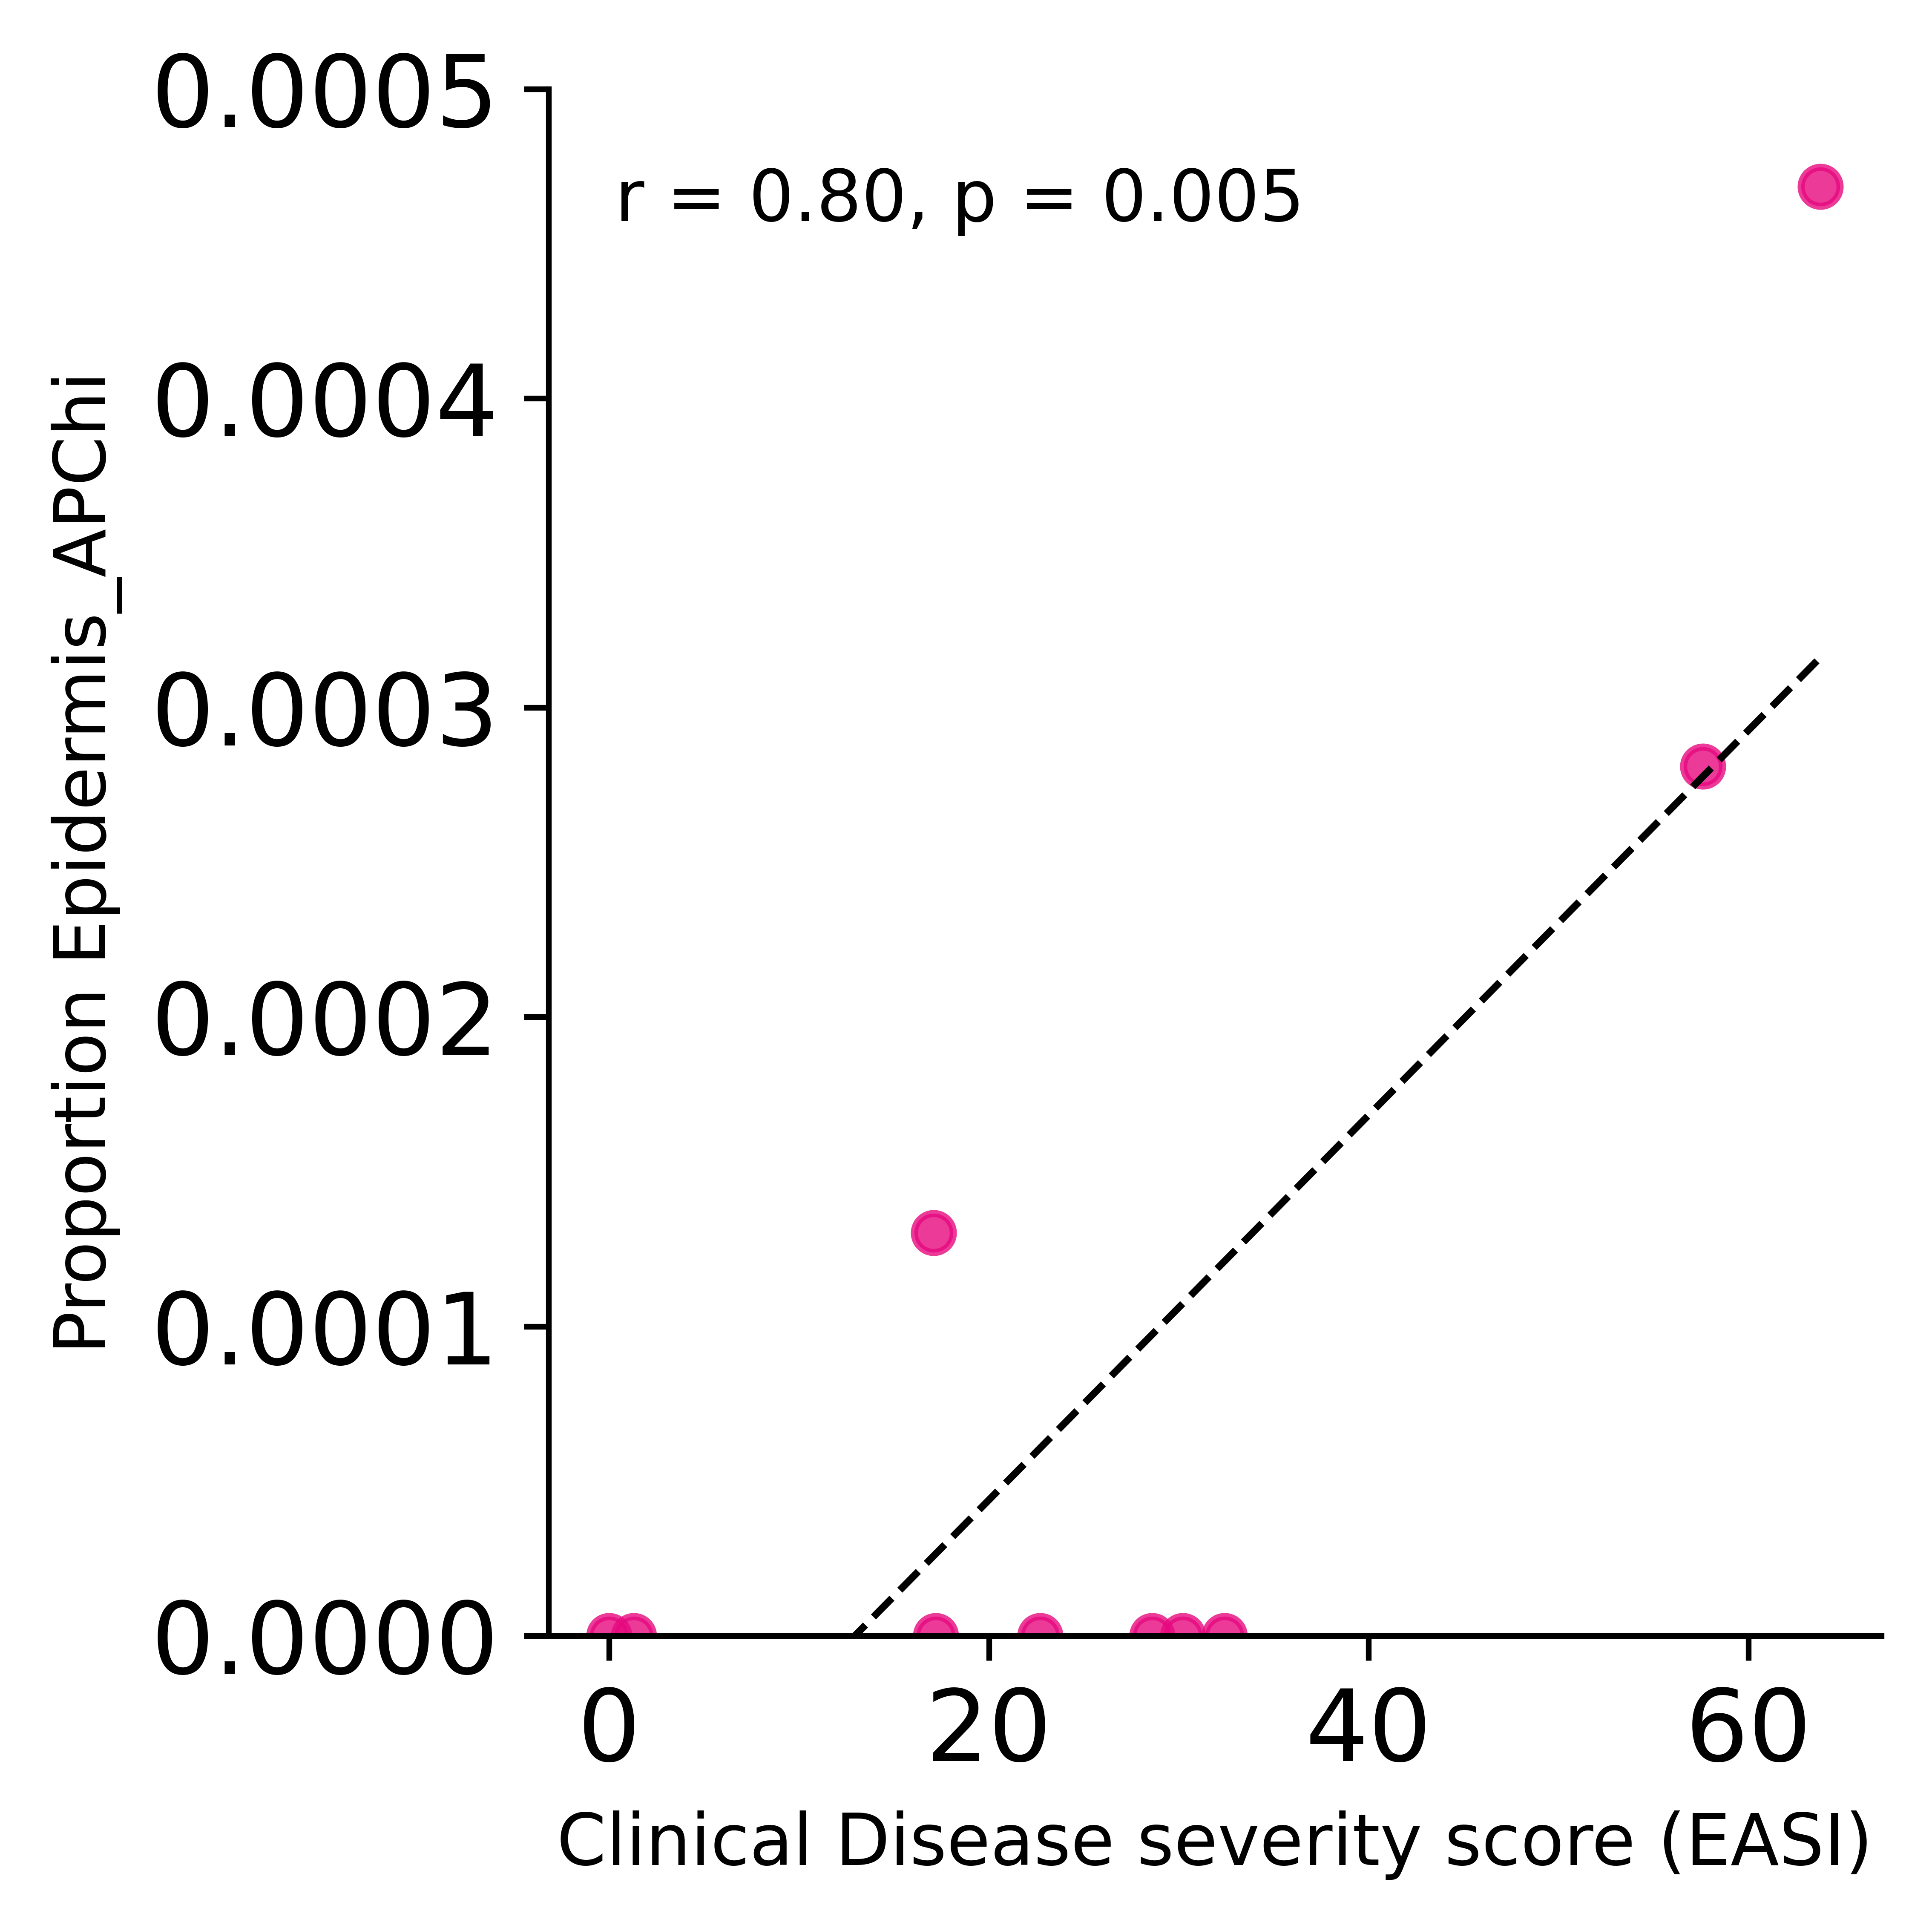

In [8]:
adata_5k_i = adata_5k[adata_5k.obs["Site_status"] == "Non-lesional"]

subset = adata_5k_i.obs[adata_5k_i.obs["niche19"] == "Epidermis_APChi"]
proportion_data = subset.groupby("Sanger patient ID").size() / adata_5k.obs.groupby("Sanger patient ID").size()

data = pd.DataFrame({
    "baseline_severity": adata_5k.obs.groupby("Sanger patient ID")["baseline_severity"].first().astype(float),
    "proportion_epidermis_mid_inflammatory": proportion_data
}).reset_index()

data = data.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["baseline_severity", "proportion_epidermis_mid_inflammatory"]
)

from adjustText import adjust_text

plt.figure(figsize=(4,4), dpi=600)
plt.scatter(
    data["baseline_severity"],
    data["proportion_epidermis_mid_inflammatory"],
    color="#e6097f", alpha=0.8, s=30
)

x = data["baseline_severity"]
y = data["proportion_epidermis_mid_inflammatory"]

r, pval = stats.pearsonr(x, y)

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
line_x = np.linspace(x.min(), x.max(), 100)
line_y = slope * line_x + intercept
plt.plot(line_x, line_y, color="black", linestyle="--", linewidth=1)

if pval < 0.001:
    p_text = "<0.001"
else:
    p_text = f"{pval:.3f}"

plt.text(
    0.05, 0.95,
    f"r = {r:.2f}, p = {p_text}",
    transform=plt.gca().transAxes,
    ha="left", va="top", fontsize=10
)

plt.xlabel("Clinical Disease severity score (EASI)", fontsize=10)
plt.ylabel("Proportion Epidermis_APChi", fontsize=10)
plt.ylim(0, 0.0005)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid(False)
plt.tight_layout()
plt.savefig("figures/e4g_NONLESIONAL_SEVERITY.pdf", dpi=300, bbox_inches="tight")
plt.show()